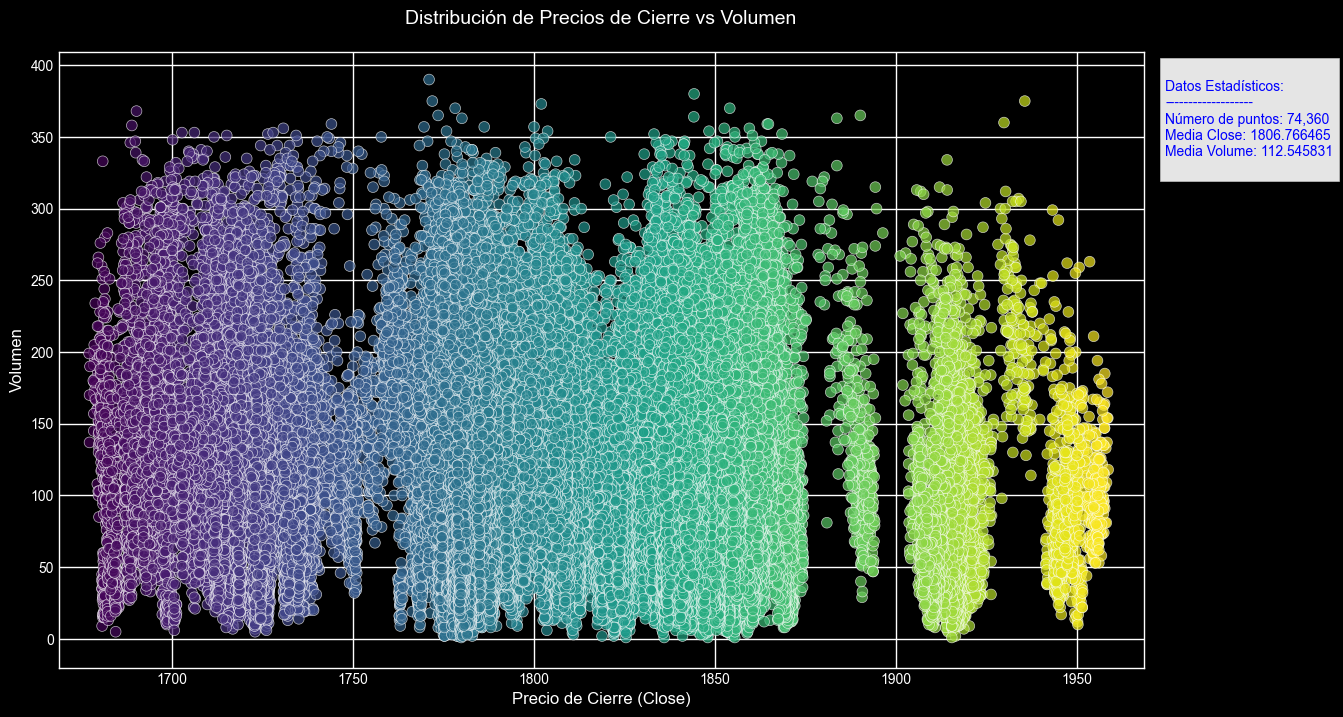

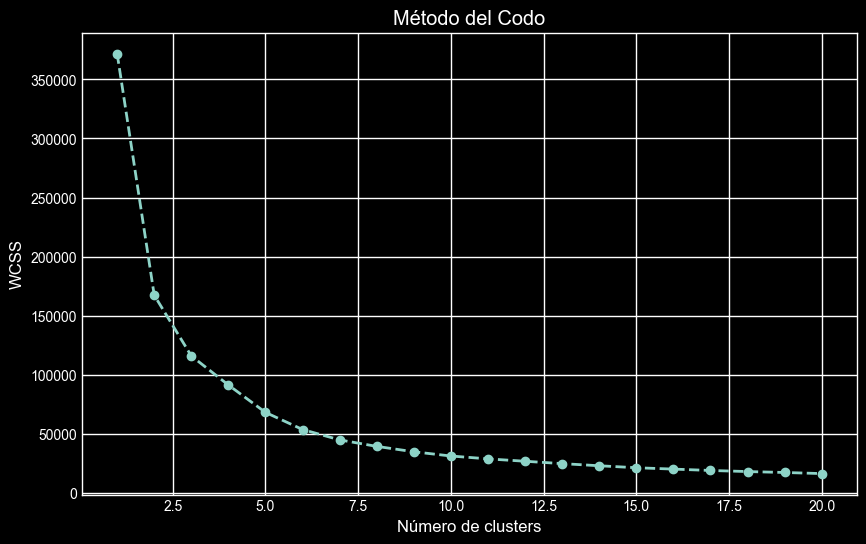

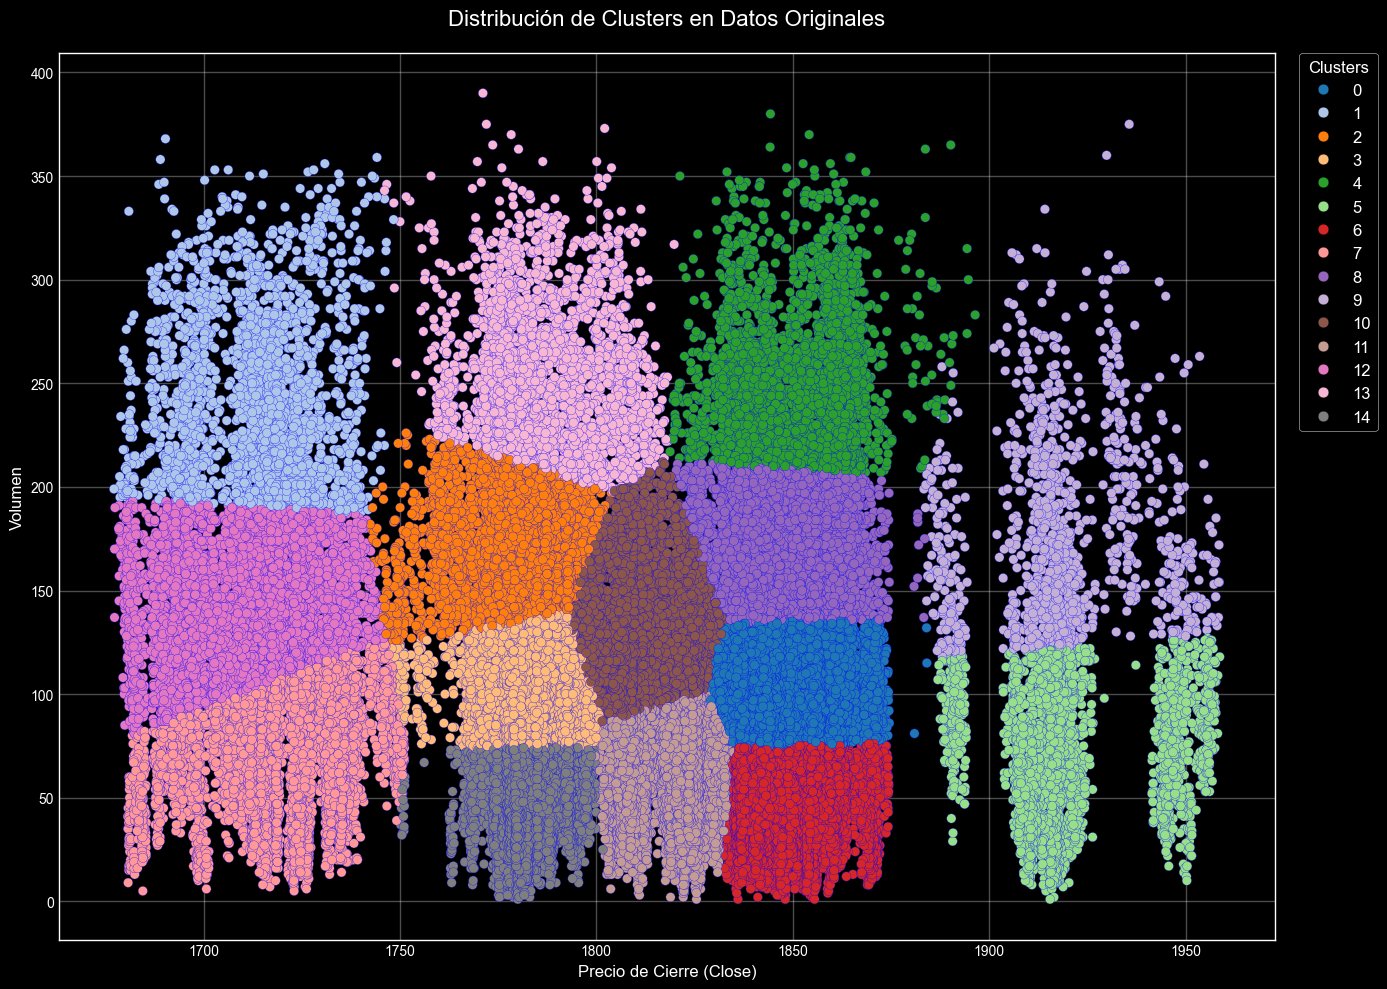

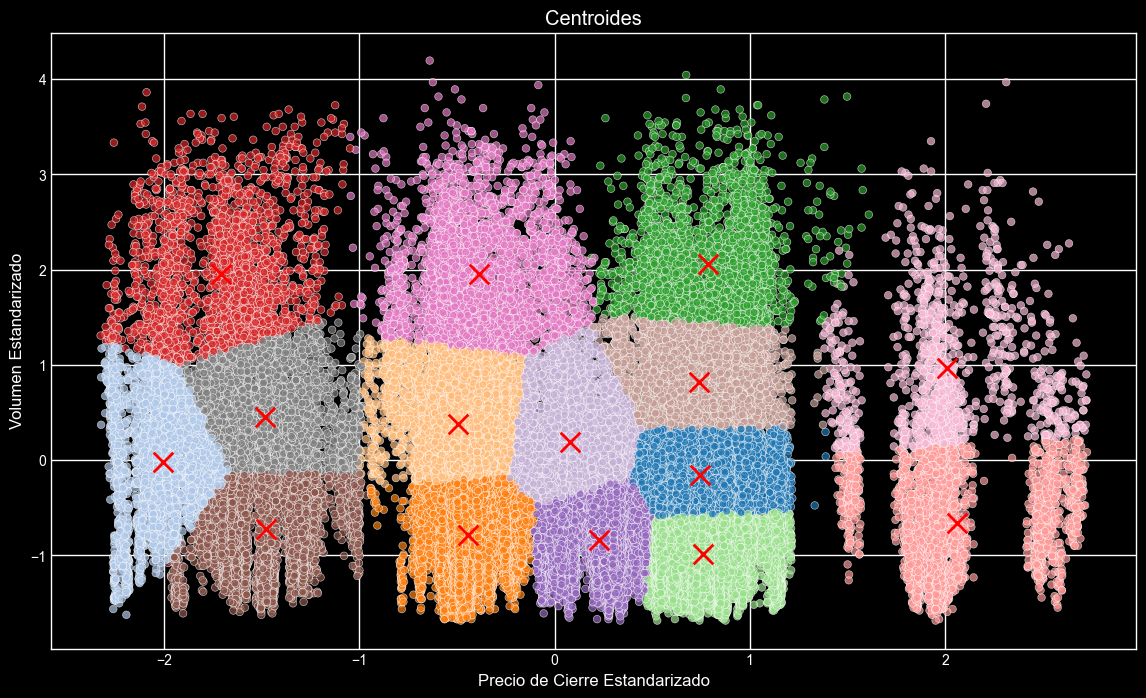

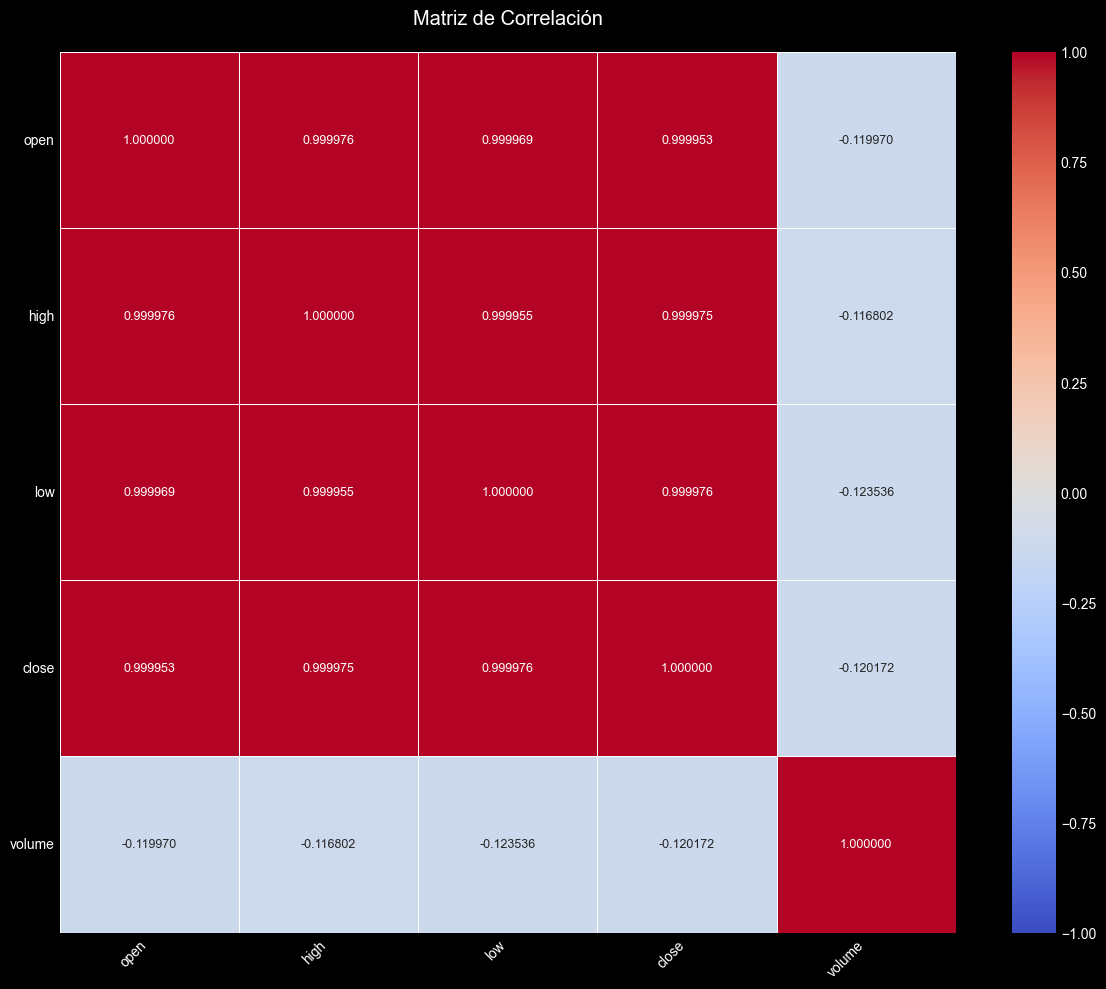

In [259]:
# #####################################################
# Traducción a Python de codigo de R 
# CLASIFICACIÓN DE PRECIOS DEL ORO USANDO K-MEANS
# Guillermo Cardenas
# #####################################################

# Librerías equivalentes en Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# ---------------------
# 1. CARGA DE DATOS
# ---------------------
# Equivalente a read_csv de R
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Eliminar primeras dos columnas 
XAUUSD_60 = train_data.drop(train_data.columns[[0, 1]], axis=1)
XAUUSD_60_test = test_data.drop(test_data.columns[[0, 1]], axis=1)

# ---------------------
# 2. PREPROCESAMIENTO
# ---------------------
# Escalado de datos (equivalente a scale())
scaler = StandardScaler()
XAUUSD_60_scaled = scaler.fit_transform(XAUUSD_60)
XAUUSD_60_test_scaled = scaler.transform(XAUUSD_60_test)

# Convertir a DataFrame
XAUUSD_60_scaled = pd.DataFrame(XAUUSD_60_scaled, columns=XAUUSD_60.columns)
XAUUSD_60_test_scaled = pd.DataFrame(XAUUSD_60_test_scaled, columns=XAUUSD_60_test.columns)


# Crear figura y eje
fig, ax = plt.subplots(figsize=(14, 8))

# --------------------------------------------------
# 3. GRAFICO DE DISTRIBUCION DE DATOS
# --------------------------------------------------

scatter = ax.scatter(
    valid_data['close'],
    valid_data['volume'],
    c=np.log10(valid_data['close']),  # Usar datos validados
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',  # Color más neutro para bordes
    linewidth=0.5,
    s=60
)
# Texto con estadísticas
# --------------------------------------------------
stats_text = f'''
Datos Estadísticos:
-------------------
Número de puntos: {len(valid_data):,}
Media Close: {valid_data['close'].mean():.6f}
Media Volume: {valid_data['volume'].mean():.6f}
'''

# Posición relativa al eje 
ax.text(
    1.02,  # x: 2% fuera del eje derecho
    0.98,  # y: 2% debajo del borde superior
    stats_text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc'),
    fontsize=10,
    color = 'b'
)

# --------------------------------------------------
# Calcular límites automáticos con márgenes seguros
x_min = valid_data['close'].min() * 0.995
x_max = valid_data['close'].max() * 1.005
y_min = valid_data['volume'].min() * -20 
y_max = valid_data['volume'].max() * 1.05

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Títulos y etiquetas
ax.set_title('Distribución de Precios de Cierre vs Volumen', 
            pad=20, fontsize=14)
ax.set_xlabel('Precio de Cierre (Close)', fontsize=12)
ax.set_ylabel('Volumen', fontsize=12)

# Ajuste final del layout
plt.show()

# ---------------------
# 4. MÉTODO DEL CODO
# ---------------------
# Cálculo de WCSS (equivalente al loop for de R)
wcss = []
for i in range(1, 21):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=10000, n_init=10)
    kmeans.fit(XAUUSD_60_scaled)
    wcss.append(kmeans.inertia_)

# Gráfico del método del codo
plt.style.use('dark_background')
plt.figure(figsize=(10,6))
plt.plot(range(1,21), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

# ---------------------
# 5. APLICACIÓN K-MEANS
# ---------------------
# Usando 15 clusters como en el ejemplo original
kmeans = KMeans(n_clusters=15, init='k-means++', max_iter=10000, n_init=10)
clusters = kmeans.fit_predict(XAUUSD_60_scaled)

# Añadir columna de clusters al DataFrame
XAUUSD_60_scaled['cluster'] = clusters

# -------------------------------------
# 6. Gráfico de dispersión 
# -------------------------------------

plt.figure(figsize=(16, 10))

scatter = sns.scatterplot(
    x='close',
    y='volume',
    hue='cluster',
    data=XAUUSD_60_original,
    palette=paleta,
    s=45,
    edgecolor='b',
    linewidth=0.2,
    legend='full'
)

# Ordenar leyenda 
unique_labels = list(dict.fromkeys(labels))  # Mantener orden original
plt.legend(
    handles[:len(unique_labels)],
    unique_labels,
    title='Clusters',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    frameon=True,
    fontsize='large',
    title_fontsize='large',
    ncol=1
)

# -------------------------------------
plt.title('Distribución de Clusters en Datos Originales', pad=20, fontsize=16)
plt.xlabel('Precio de Cierre (Close)', fontsize=12)
plt.ylabel('Volumen', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajustar márgenes
plt.tight_layout()
plt.subplots_adjust(right=0.8)  # Espacio para leyenda
plt.show()


# ---------------------
# 7. VISUALIZACIÓN 
# ---------------------
plt.figure(figsize=(14, 8))

# Gráfico de dispersión 
sns.scatterplot(
    x='close', 
    y='volume', 
    hue='cluster', 
    data=XAUUSD_60_scaled, 
    palette=paleta,
    s=30,
    alpha=0.7,
    legend=False  
)

# Centróides marcados con 'x' 
plt.scatter(
    kmeans.cluster_centers_[:,3], 
    kmeans.cluster_centers_[:,4], 
    s=200, 
    c='red', 
    marker='x',  # Cambiamos el marcador
    linewidths=2,
    label='Centróides'
)

plt.title('Centroides')
plt.xlabel('Precio de Cierre Estandarizado')
plt.ylabel('Volumen Estandarizado')
plt.show()

# ---------------------
# 7. MATRIZ DE CORRELACIÓN
# ---------------------


# Crear copia sin la columna de cluster
df_correlacion = XAUUSD_60_scaled.drop(columns=['cluster']).copy()

# Calcular matriz de correlación con 3 decimales
corr_matrix = df_correlacion.corr().round(6)

# Configurar gráfico
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".6f",  # Mostrar 3 decimales fijos
    annot_kws={"size": 9},
    linewidths=0.5,
    vmin=-1,
    vmax=1
)


plt.title('Matriz de Correlación', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

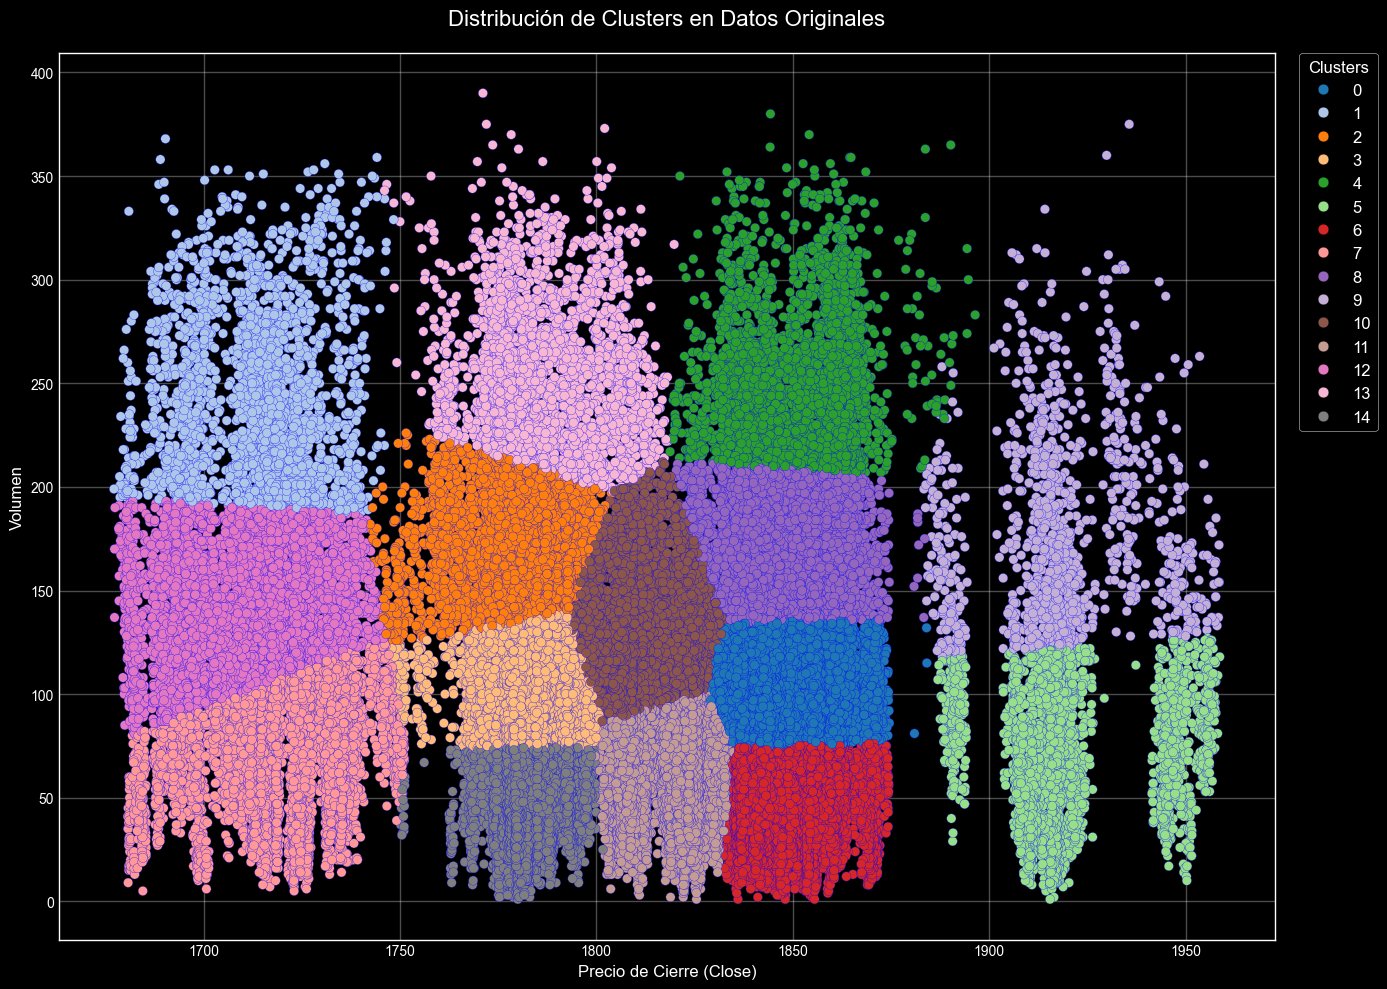

In [254]:
plt.figure(figsize=(16, 10))

# -------------------------------------
# 1. Gráfico de dispersión por clúster
# -------------------------------------
scatter = sns.scatterplot(
    x='close',
    y='volume',
    hue='cluster',
    data=XAUUSD_60_original,
    palette=paleta,
    s=45,
    edgecolor='b',
    linewidth=0.2,
    legend='full'
)

# Ordenar leyenda 
unique_labels = list(dict.fromkeys(labels))  # Mantener orden original
plt.legend(
    handles[:len(unique_labels)],
    unique_labels,
    title='Clusters',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    frameon=True,
    fontsize='large',
    title_fontsize='large',
    ncol=1
)


# -------------------------------------
plt.title('Distribución de Clusters en Datos Originales', pad=20, fontsize=16)
plt.xlabel('Precio de Cierre (Close)', fontsize=12)
plt.ylabel('Volumen', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajustar márgenes
plt.tight_layout()
plt.subplots_adjust(right=0.8)  # Espacio para leyenda
plt.show()

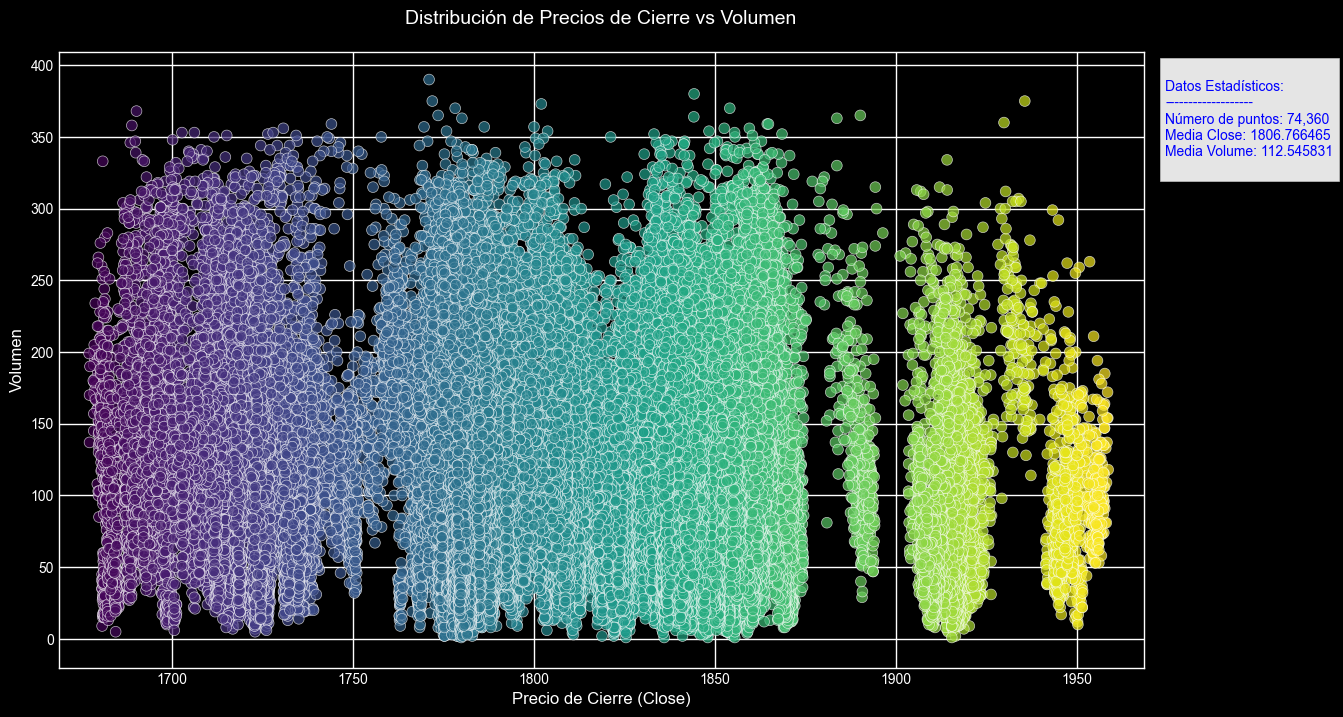

In [ ]:
# Crear figura y eje
fig, ax = plt.subplots(figsize=(14, 8))

# --------------------------------------------------
# 1. Scatter plot 
# --------------------------------------------------

scatter = ax.scatter(
    valid_data['close'],
    valid_data['volume'],
    c=np.log10(valid_data['close']),  # Usar datos validados
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',  # Color más neutro para bordes
    linewidth=0.5,
    s=60
)
# 3. Texto con estadísticas (posición corregida)
# --------------------------------------------------
stats_text = f'''
Datos Estadísticos:
-------------------
Número de puntos: {len(valid_data):,}
Media Close: {valid_data['close'].mean():.6f}
Media Volume: {valid_data['volume'].mean():.6f}
'''

# Posición relativa al eje (coordenadas normalizadas)
ax.text(
    1.02,  # x: 2% fuera del eje derecho
    0.98,  # y: 2% debajo del borde superior
    stats_text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc'),
    fontsize=10,
    color = 'b'
)

# --------------------------------------------------
# Calcular límites automáticos con márgenes seguros
x_min = valid_data['close'].min() * 0.995
x_max = valid_data['close'].max() * 1.005
y_min = valid_data['volume'].min() * -20 
y_max = valid_data['volume'].max() * 1.05

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Títulos y etiquetas
ax.set_title('Distribución de Precios de Cierre vs Volumen', 
            pad=20, fontsize=14)
ax.set_xlabel('Precio de Cierre (Close)', fontsize=12)
ax.set_ylabel('Volumen', fontsize=12)

# Ajuste final del layout
plt.show()